In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import pm4py
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
from enrichment import *
from feature_engineering import *


# Data Exploration and Preparation

In [103]:
event_log = pm4py.read_xes("data/BPI Challenge 2017.xes")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [104]:
display(event_log)
print(event_log.shape[0])
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


1202267
31509


In [105]:
# Filter for Application events
event_log = event_log[event_log["EventOrigin"] == "Application"]
event_log.reset_index()
print(event_log.shape[0])
print(event_log["case:concept:name"].nunique())


239595
31509


In [106]:
event_log.reset_index()
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,statechange,User_52,A_Complete,Application,ApplState_946455804,complete,2016-01-02 11:30:28.633000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202247,statechange,User_1,A_Submitted,Application,ApplState_2065621861,complete,2016-12-31 21:37:54.247000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202251,statechange,User_1,A_Concept,Application,ApplState_291481081,complete,2016-12-31 21:38:27.252000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202253,statechange,User_96,A_Accepted,Application,ApplState_320370852,complete,2017-01-02 19:21:15.965000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202260,statechange,User_96,A_Complete,Application,ApplState_1120616436,complete,2017-01-02 19:27:20.474000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
event_log.info()
print(event_log["case:concept:name"].nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 239595 entries, 0 to 1202264
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   Action                 239595 non-null  object             
 1   org:resource           239595 non-null  object             
 2   concept:name           239595 non-null  object             
 3   EventOrigin            239595 non-null  object             
 4   EventID                239595 non-null  object             
 5   lifecycle:transition   239595 non-null  object             
 6   time:timestamp         239595 non-null  datetime64[ns, UTC]
 7   case:LoanGoal          239595 non-null  object             
 8   case:ApplicationType   239595 non-null  object             
 9   case:concept:name      239595 non-null  object             
 10  case:RequestedAmount   239595 non-null  float64            
 11  FirstWithdrawalAmount  0 non-null       flo

# Event Log Enrichment

In [108]:
event_log = remove_empty_columns(event_log)
event_log = add_inter_event_time(event_log)
event_log = event_add_relative_case_time(event_log)
event_log = event_add_relative_log_time(event_log)

In [109]:
display(event_log)
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,time_since_prev,relative_case_time,relative_log_time
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,0.0,0,0
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,0.0,0,0
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,0.0,0,0
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,1.0,1,1
15,statechange,User_52,A_Complete,Application,ApplState_946455804,complete,2016-01-02 11:30:28.633000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202247,statechange,User_1,A_Submitted,Application,ApplState_2065621861,complete,2016-12-31 21:37:54.247000+00:00,Home improvement,New credit,Application_1350494635,20000.0,0.0,0,365
1202251,statechange,User_1,A_Concept,Application,ApplState_291481081,complete,2016-12-31 21:38:27.252000+00:00,Home improvement,New credit,Application_1350494635,20000.0,0.0,0,365
1202253,statechange,User_96,A_Accepted,Application,ApplState_320370852,complete,2017-01-02 19:21:15.965000+00:00,Home improvement,New credit,Application_1350494635,20000.0,1.0,1,367
1202260,statechange,User_96,A_Complete,Application,ApplState_1120616436,complete,2017-01-02 19:27:20.474000+00:00,Home improvement,New credit,Application_1350494635,20000.0,0.0,1,367


31509


In [110]:
case_timestamps = event_log.groupby("case:concept:name")["time:timestamp"]
case_durations = case_timestamps.max() - case_timestamps.min()
avg_case_duration = case_durations.mean()
max_case_duration = case_durations.max()
min_case_duration = case_durations.min()
display(max_case_duration)
display(min_case_duration)
display(case_durations)
display(avg_case_duration)


Timedelta('169 days 01:44:19.800000')

Timedelta('0 days 00:02:11.132000')

case:concept:name
Application_1000086665   32 days 14:03:15.037000
Application_1000158214    8 days 00:47:34.434000
Application_1000311556   30 days 14:04:11.228000
Application_1000334415   13 days 15:06:16.591000
Application_1000339879   12 days 20:14:38.437000
                                   ...          
Application_999507989     6 days 07:14:35.733000
Application_999544538    79 days 18:48:35.266000
Application_999632431    31 days 18:35:34.282000
Application_999993467    13 days 18:42:42.747000
Application_999993812    17 days 16:27:25.960000
Name: time:timestamp, Length: 31509, dtype: timedelta64[ns]

Timedelta('21 days 19:57:47.486496366')

# Prefix Extraction

In [111]:



def extract_prefixes_with_time_cutoff(event_log, cutoff_in_days, target, holidays):
    all_prefixes = []
    static_attributes, dynamic_attributes = detect_static_attributes(event_log)
    exclude = {"time:timestamp", "relative_case_time", "relative_log_time", "time_since_prev"}
    static_attributes = [a for a in static_attributes if a not in exclude]
    dynamic_attributes = [a for a in dynamic_attributes if a not in exclude]
    reference_date = event_log["time:timestamp"].min()
    activities_to_flag = event_log["concept:name"].unique()
    for case, group in event_log.groupby("case:concept:name"):
        features = {}
        prefix = group[group["relative_case_time"] < cutoff_in_days]
        prefix_start_time = group.iloc[0]["time:timestamp"]
        prefix_end_time = group.iloc[-1]["time:timestamp"]
        if group["relative_case_time"].max() < cutoff_in_days:
            continue
        A_pending_events = group[group["concept:name"] == "A_Pending"]
        if len(A_pending_events) == 0:
            continue
        A_Pending_absolute_time = A_pending_events.iloc[0]["relative_log_time"]
        add_case_attributes(prefix, features, static_attributes)
        add_event_attributes(prefix, features, dynamic_attributes)
        add_time_features(prefix, features)
        # add_attributes_from_last_event(prefix, features)
        add_activity_counts(prefix, features, activities_to_flag)
        # add_activity_flags(prefix, features, activities_to_flag)
        add_activity_start_times(prefix, features, reference_date, activities_to_flag)
        add_time_based_features(prefix, features, prefix_start_time)
        add_prefix_stats(prefix, features, case)
        # add_numeric_aggregates(prefix, features)
        add_resource_features(prefix, features)
        # add_days_since_reference(prefix, features, reference_date)
        add_holiday_features(prefix, features, prefix_end_time, holidays)
        # activity_pairs = [("Send Fine", "Add penalty", "fine_to_penalty")]
        # add_pairwise_delays(prefix, features, activity_pairs)
        features["target"] = A_Pending_absolute_time
        all_prefixes.append(features)
    return all_prefixes

     
        
    


In [112]:
nl_holidays = holidays.NL(years=2016)
for h in nl_holidays.items():
    print(h)


(datetime.date(2016, 1, 1), 'Nieuwjaarsdag')
(datetime.date(2016, 3, 25), 'Goede Vrijdag')
(datetime.date(2016, 3, 27), 'Eerste paasdag')
(datetime.date(2016, 3, 28), 'Tweede paasdag')
(datetime.date(2016, 4, 27), 'Koningsdag')
(datetime.date(2016, 5, 5), 'Hemelvaartsdag')
(datetime.date(2016, 5, 15), 'Eerste Pinksterdag')
(datetime.date(2016, 5, 16), 'Tweede Pinksterdag')
(datetime.date(2016, 12, 25), 'Eerste Kerstdag')
(datetime.date(2016, 12, 26), 'Tweede Kerstdag')


In [113]:
print(event_log["case:concept:name"].nunique())

31509


In [114]:
cutoff_in_days = 5
target = "A_Pending"
prefix_log = extract_prefixes_with_time_cutoff(event_log, cutoff_in_days, target, nl_holidays)

In [115]:
prefix_log = pd.DataFrame(prefix_log)
prefix_log["case:concept:name"].nunique()

16882

In [116]:
display(prefix_log)

,EventOrigin,lifecycle:transition,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,Action_last,org:resource_last,concept:name_last,EventID_last,...,case_start_year,case_id,prefix_length,avg_time_between_events,max_time_between_events,number_of_unique_resources,num_holidays_in_prefix,days_to_next_holiday,days_since_last_holiday,target
0,Application,complete,Home improvement,New credit,Application_1000158214,12500.0,statechange,User_32,A_Complete,ApplState_658801120,...,2016,Application_1000158214,5,0.60,3.0,2,0,198,25,161
1,Application,complete,Existing loan takeover,New credit,Application_1000339879,37500.0,statechange,User_28,A_Complete,ApplState_947494278,...,2016,Application_1000339879,5,0.00,0.0,2,3,28,2,88
2,Application,complete,Existing loan takeover,New credit,Application_100034150,5000.0,statechange,User_37,A_Complete,ApplState_1870412122,...,2016,Application_100034150,5,0.00,0.0,3,0,17,67,67
3,Application,complete,Car,New credit,Application_1000386745,5000.0,statechange,User_77,A_Complete,ApplState_386859426,...,2016,Application_1000386745,5,0.00,0.0,2,0,19,204,340
4,Application,complete,"Other, see explanation",New credit,Application_1000474975,50000.0,statechange,User_7,A_Complete,ApplState_1864583080,...,2016,Application_1000474975,4,0.00,0.0,1,0,179,44,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Application,complete,Existing loan takeover,New credit,Application_999487618,20000.0,statechange,User_56,A_Complete,ApplState_548457952,...,2016,Application_999487618,5,0.00,0.0,2,0,118,105,241
16878,Application,complete,Not speficied,New credit,Application_999507989,24000.0,statechange,User_16,A_Complete,ApplState_951433585,...,2016,Application_999507989,5,0.00,0.0,2,0,2,82,82
16879,Application,complete,Car,New credit,Application_999544538,50000.0,statechange,User_27,A_Complete,ApplState_239134320,...,2016,Application_999544538,5,0.00,0.0,2,2,152,71,206
16880,Application,complete,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_49,A_Complete,ApplState_1012012747,...,2016,Application_999993467,4,0.25,1.0,2,0,159,64,200


# Feature Encoding

In [117]:
from sklearn.preprocessing import LabelEncoder

# Separate features and target
feature_cols = [col for col in prefix_log.columns 
                if col not in ['case:concept:name', 'target', 'case_id']]

X = prefix_log[feature_cols].copy()
y = prefix_log['target']

# Detect and label encode categorical columns
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Convert everything to numeric and fill NaN with medians
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

print(f"Feature matrix shape: {X.shape}")
display(X.head())

Feature matrix shape: (16882, 52)


,EventOrigin,lifecycle:transition,case:LoanGoal,case:ApplicationType,case:RequestedAmount,Action_last,org:resource_last,concept:name_last,EventID_last,relative_log_time,...,start_day_of_week,start_month,case_start_year,prefix_length,avg_time_between_events,max_time_between_events,number_of_unique_resources,num_holidays_in_prefix,days_to_next_holiday,days_since_last_holiday
0,0,0,6,1,12500.0,0,63,1,13851,156,...,3,6,2016,5,0.6,3.0,2,0,198,25
1,0,0,4,1,37500.0,0,58,1,16413,76,...,3,3,2016,5,0.0,0.0,2,3,28,2
2,0,0,4,1,5000.0,0,68,1,7574,56,...,4,2,2016,5,0.0,0.0,3,0,17,67
3,0,0,2,1,5000.0,0,112,1,11477,329,...,4,11,2016,5,0.0,0.0,2,0,19,204
4,0,0,9,1,50000.0,0,104,1,7525,167,...,3,6,2016,4,0.0,0.0,1,0,179,44


In [118]:
print(categorical_cols)

['EventOrigin', 'lifecycle:transition', 'case:LoanGoal', 'case:ApplicationType', 'Action_last', 'org:resource_last', 'concept:name_last', 'EventID_last']


# Model Building and Training

In [119]:
# test-train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [120]:
from aix360.algorithms.rbm.features import FeatureBinarizer
from aix360.algorithms.rbm.linear_regression import LinearRuleRegression
from aix360.algorithms.rbm.logistic_regression import LogisticRuleRegression


fb = FeatureBinarizer(numThresh=9)
X_train_bin = fb.fit_transform(X_train)
X_test_bin = fb.transform(X_test)

glrm = LinearRuleRegression(lambda0=0.05, lambda1=0.01)
glrm.fit(X_train_bin, y_train, X_train)  # X_train passed as Xstd for numeric features
# glrm = LogisticRuleRegression(lambda0=0.05, lambda1=0.01)
# glrm.fit(X_train_bin, y_train, X_train)

# Predict and evaluate
y_pred_glrm = glrm.predict(X_test_bin, X_test)
mae = mean_absolute_error(y_test, y_pred_glrm)
print(f"MAE: {mae:.2f} days")

# Inspect the rules
print(glrm.explain())

MAE: 9.35 days
                                                 rule coefficient
0                                         (intercept)  356.645507
1                                    start_month <= 3  -32.701215
2                  A_Concept_abs_days::start <= 41.00  -30.291147
3                 A_Concept_abs_days::start <= 257.00  -29.866393
4   A_Concept_abs_days::start <= 323.00 AND num_ho...  -26.609706
5                                    start_month <= 5  -26.346413
6                                start_month <= 10.00  -23.678973
7                                 start_month <= 8.00  -18.775732
8                  A_Concept_abs_days::start <= 80.00   -18.76323
9      A_Create Application_abs_days::start <= 225.00  -18.750248
10     A_Create Application_abs_days::start <= 123.00  -18.325488
11                A_Concept_abs_days::start <= 123.00  -18.319278
12  A_Concept_abs_days::start <= 323.00 AND num_ho...  -18.020447
13                                start_month <= 9.00  -17.23

In [121]:
model = RandomForestRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [122]:
from sklearn.metrics import root_mean_squared_error


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae} days")
print(f"Root Mean Squared Error: {rmse} days")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: 0.4422445957950842 days
Root Mean Squared Error: 0.879833281647282 days
R² Score: 0.9999


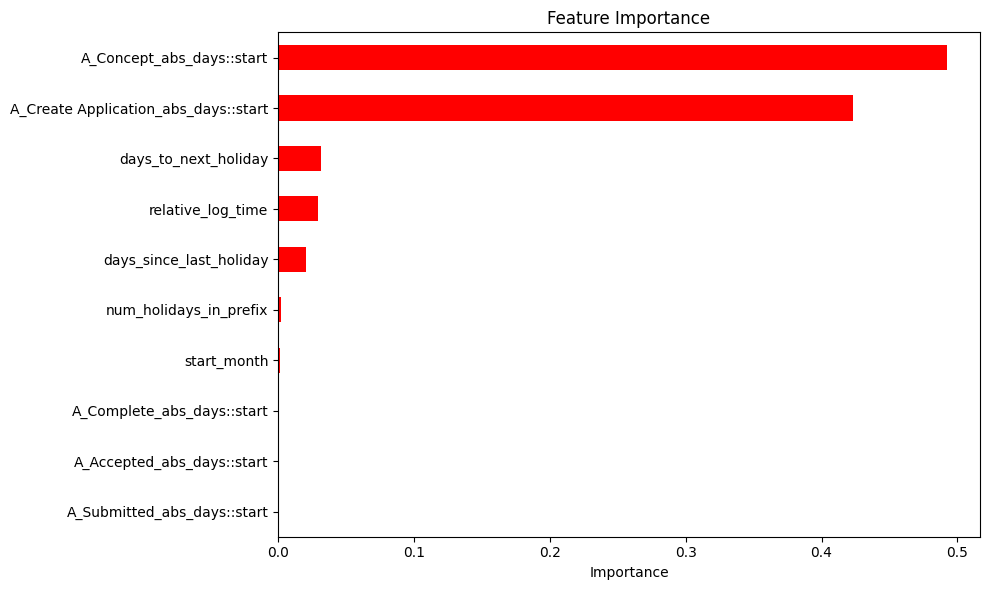

In [123]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Interpretation

In [124]:
import plotly.express as px
A_pending_events = event_log[event_log["concept:name"] == "A_Pending"]
fig = px.histogram(A_pending_events, x="relative_case_time")
fig.add_vline(x=cutoff_in_days, line_width=3, line_dash="dash", line_color="red")
fig.show()